# Course: B. Tech - Specialization Elective
## Course Code: CSET343 | Course Name: AI in Healthcare
### Year: 4th Year | Semester: VII
---
# Lab Assignment – 5: Multiclass Classification in Healthcare

### **Objective:**
This assignment provides hands-on experience with **multiclass classification** (predicting more than two target classes) applied to clinical healthcare data. We investigate the differential diagnosis of **erythemo-squamous skin diseases** using the **Dermatology Dataset**.

### **Dataset Overview: Dermatology (UCI / OpenML)**
* **Target Variable:** `class` (Multiclass: 1 to 6 representing distinct dermatological conditions)
  * **1 = Psoriasis**
  * **2 = Seborrheic Dermatitis**
  * **3 = Lichen Planus**
  * **4 = Pityriasis Rosea**
  * **5 = Chronic Dermatitis**
  * **6 = Pityriasis Rubra Pilaris**
* **Features:** 34 total attributes (12 clinical evaluation attributes + 21 histopathological microscopic evaluation attributes + 1 patient age feature).

---
## Notebook Table of Contents
1. [Environment Setup & Library Imports](#setup)
2. [Task 1: Data Acquisition and Exploration](#task1)
   - 1.1 Data Loading & Schema Inspection
   - 1.2 Summary Statistics for Clinical & Histopathological Features
   - 1.3 Missing Values, Duplicates & Outlier Handling
   - 1.4 Exploratory Data Visualizations (Class Distribution, Histograms, Boxplots, Heatmap)
   - 1.5 Discussion on Class Imbalance & Clinical Implications
3. [Task 2: Data Preprocessing](#task2)
   - 2.1 Target Variable Encoding
   - 2.2 Stratified Train/Test Split (80/20)
   - 2.3 Feature Standardization via StandardScaler
4. [Task 3: Model Training and Basic Evaluation](#task3)
   - 3.1 Implementation of 5 ML Algorithms (Logistic Regression, KNN, SVM, Random Forest, Gradient Boosting)
   - 3.2 Evaluation Across Core Metrics (Accuracy, Precision, Recall, F1-Score per Class)
   - 3.3 Confusion Matrix Visualizations
   - 3.4 Multiclass One-vs-Rest ROC Curves & AUC Scores
   - 3.5 Comparative Performance Summary Table & Visual Benchmarking
   - 3.6 Feature Importance Analysis (Histopathological vs Clinical Dominance)
   - 3.7 Comprehensive Results Interpretation & Healthcare Diagnostic Insights


<a id='setup'></a>
## 1. Environment Setup & Library Imports
We import standard data science and machine learning libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`, and `scikit-learn` algorithms and evaluation metrics.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn data acquisition and preprocessing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize

# Multiclass Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

# Configuration & styling
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

print("✓ All required libraries imported successfully.")


✓ All required libraries imported successfully.


<a id='task1'></a>
---
## Task 1: Data Acquisition and Exploration

### 1.1 Data Loading & Schema Inspection
The dermatology dataset contains patient records with clinical observations and microscopic histopathological examination scores. The target variable is one of 6 erythemo-squamous skin diseases.


In [2]:
# Define human-readable disease mapping
DISEASE_MAP = {
    1: 'Psoriasis',
    2: 'Seborrheic Dermatitis',
    3: 'Lichen Planus',
    4: 'Pityriasis Rosea',
    5: 'Chronic Dermatitis',
    6: 'Pityriasis Rubra Pilaris'
}

data_path = 'data/dermatology.csv'
if os.path.exists(data_path):
    print(f"Loading dataset from local cache: '{data_path}'...")
    df = pd.read_csv(data_path)
else:
    print("Fetching dermatology dataset from OpenML...")
    derm = fetch_openml('dermatology', version=1, as_frame=True)
    df = derm.frame
    os.makedirs('data', exist_ok=True)
    df.to_csv(data_path, index=False)

# Standardize target column type to int
df['class'] = pd.to_numeric(df['class'])

print(f"✓ Dataset loaded successfully!")
print(f"Total Patient Records (Rows): {df.shape[0]}")
print(f"Total Attributes (Columns):   {df.shape[1]} (34 Features + 1 Target 'class')")
print("\nFirst 5 rows of the Dermatology Dataset:")
df.head()


Loading dataset from local cache: 'data/dermatology.csv'...
✓ Dataset loaded successfully!
Total Patient Records (Rows): 366
Total Attributes (Columns):   35 (34 Features + 1 Target 'class')

First 5 rows of the Dermatology Dataset:


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45.0,3


### 1.2 Summary Statistics
Let us compute the summary statistics (**mean, median, standard deviation, min, 25%, 75%, max**) for all clinical and histopathological features.
* **Clinical features (0-11):** Scaled on an ordinal scale of 0 to 3 (0: absent, 1: mild, 2: moderate, 3: severe), family history is boolean (0 or 1), and Age is continuous.
* **Histopathological features (12-33):** Derived from skin biopsies and scored ordinally (0 to 3).


In [3]:
# Compute full descriptive summary statistics
summary_stats = df.describe().T
summary_stats['median'] = df.median(numeric_only=True)

# Select key statistics requested
key_stats = summary_stats[['mean', 'median', 'std', 'min', '25%', '75%', 'max']]
print("Summary Statistics for all features (Mean, Median, Std, Min, Quartiles, Max):")
key_stats


Summary Statistics for all features (Mean, Median, Std, Min, Quartiles, Max):


,mean,median,std,min,25%,75%,max
erythema,2.068306,2.0,0.664753,0.0,2.0,2.00,3.0
scaling,1.795082,2.0,0.701527,0.0,1.0,2.00,3.0
definite_borders,1.549180,2.0,0.907525,0.0,1.0,2.00,3.0
itching,1.366120,1.0,1.138299,0.0,0.0,2.00,3.0
koebner_phenomenon,0.633880,0.0,0.908016,0.0,0.0,1.00,3.0
polygonal_papules,0.448087,0.0,0.957327,0.0,0.0,0.00,3.0
follicular_papules,0.166667,0.0,0.570588,0.0,0.0,0.00,3.0
oral_mucosal_involvement,0.377049,0.0,0.834147,0.0,0.0,0.00,3.0
knee_and_elbow_involvement,0.614754,0.0,0.982979,0.0,0.0,1.00,3.0
scalp_involvement,0.519126,0.0,0.905639,0.0,0.0,1.00,3.0


### 1.3 Check for Missing Values, Duplicates, and Outliers
In healthcare diagnostics, missing biopsy or demographic data must be handled transparently without biasing predictions.


In [4]:
print("=== 1. Missing Values Check ===")
missing_series = df.isnull().sum()
missing_features = missing_series[missing_series > 0]

if len(missing_features) > 0:
    print(f"Features with missing values:\n{missing_features}\n")
    # In this dataset, Age has 8 missing values due to unrecorded patient records.
    median_age = df['Age'].median()
    print(f"Handling missing values: Imputing 'Age' feature using median value ({median_age:.1f} years)...")
    df['Age'] = df['Age'].fillna(median_age)
    print(f"Remaining missing values after imputation: {df.isnull().sum().sum()}")
else:
    print("No missing values found.")

print("\n=== 2. Duplicate Records Check ===")
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")
if duplicates_count > 0:
    print("Dropping duplicates to maintain data integrity...")
    df = df.drop_duplicates().reset_index(drop=True)
else:
    print("No duplicate patient entries detected.")

print("\n=== 3. Outlier Inspection for Continuous Feature ('Age') ===")
q25, q75 = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
iqr = q75 - q25
lower_bound, upper_bound = q25 - 1.5 * iqr, q75 + 1.5 * iqr
age_outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(f"Age IQR: {iqr:.2f} (Q1: {q25:.1f}, Q3: {q75:.1f})")
print(f"Age normal range: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of statistical outliers in Age: {len(age_outliers)}")
print("Note: Patient ages span pediatric to geriatric (e.g. 7 to 75 years), which are medically valid presentations; no arbitrary truncation is needed.")


=== 1. Missing Values Check ===
Features with missing values:
Age    8
dtype: int64

Handling missing values: Imputing 'Age' feature using median value (35.0 years)...
Remaining missing values after imputation: 0

=== 2. Duplicate Records Check ===
Number of duplicate rows: 0
No duplicate patient entries detected.

=== 3. Outlier Inspection for Continuous Feature ('Age') ===
Age IQR: 23.00 (Q1: 25.0, Q3: 48.0)
Age normal range: [-9.5, 82.5]
Number of statistical outliers in Age: 0
Note: Patient ages span pediatric to geriatric (e.g. 7 to 75 years), which are medically valid presentations; no arbitrary truncation is needed.


### 1.4 Exploratory Data Visualization
We visualize:
1. **Target Class Distribution**
2. **Histograms of Key Clinical Attributes**
3. **Box Plots of Key Features by Disease Class**
4. **Correlation Heatmap of Representative Features**


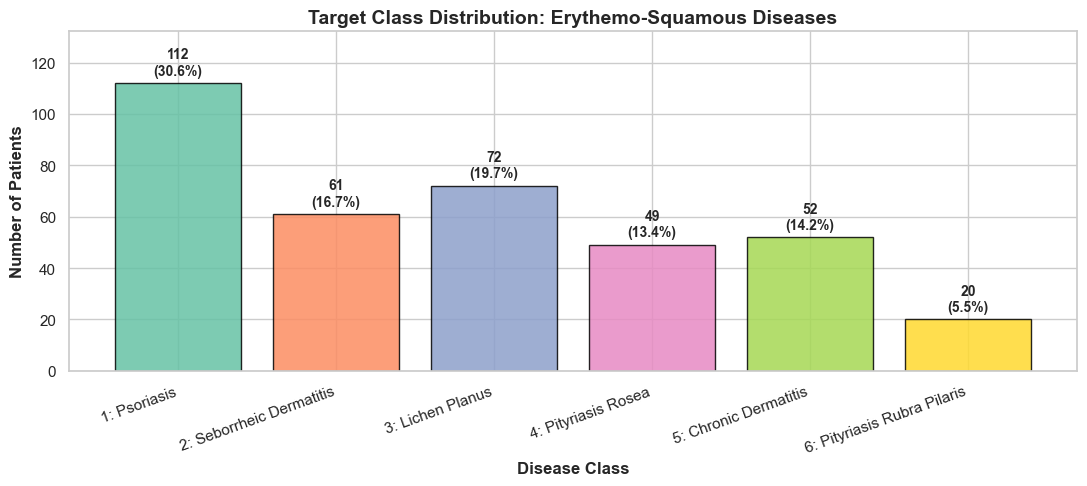

In [5]:
# 1. Target Class Distribution Plot
plt.figure(figsize=(11, 5))
class_counts = df['class'].value_counts().sort_index()
class_labels = [f"{cls}: {DISEASE_MAP[cls]}" for cls in class_counts.index]
palette = sns.color_palette("Set2", len(class_counts))

bars = plt.bar(class_labels, class_counts.values, color=palette, edgecolor='black', alpha=0.85)
plt.title("Target Class Distribution: Erythemo-Squamous Diseases", fontweight='bold', fontsize=14)
plt.xlabel("Disease Class", fontweight='bold')
plt.ylabel("Number of Patients", fontweight='bold')
plt.xticks(rotation=20, ha='right')

# Annotate counts and percentages on bars
total_patients = len(df)
for bar in bars:
    height = bar.get_height()
    pct = (height / total_patients) * 100
    plt.annotate(f'{int(height)}\n({pct:.1f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='semibold')

plt.ylim(0, max(class_counts.values) * 1.18)
plt.tight_layout()
plt.show()


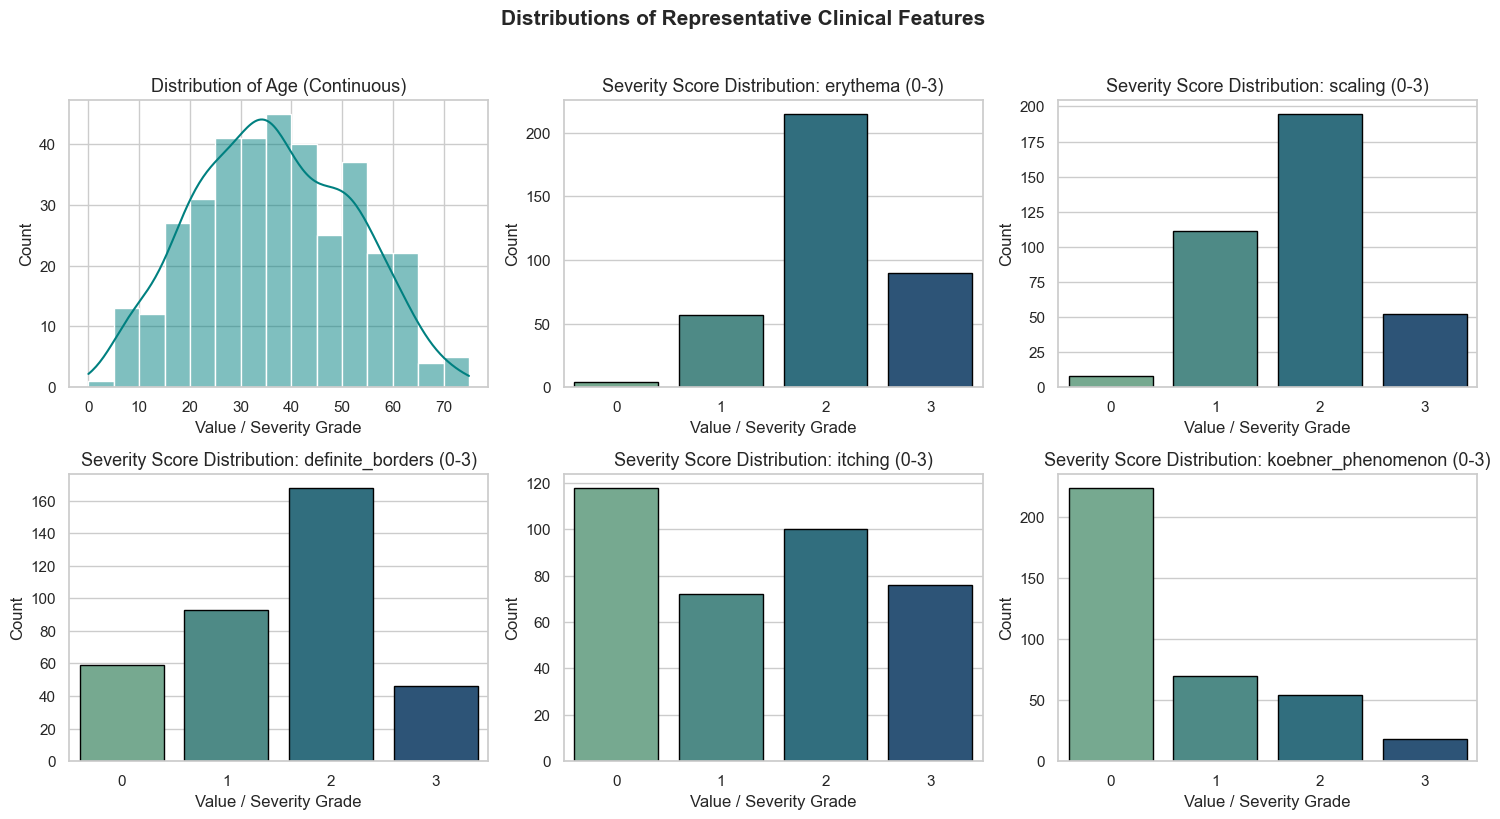

In [6]:
# 2. Histograms / Distributions of Key Clinical and Histopathological Features
key_features_to_plot = ['Age', 'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(key_features_to_plot):
    if col == 'Age':
        sns.histplot(df[col], kde=True, ax=axes[idx], color='teal', bins=15)
        axes[idx].set_title(f"Distribution of {col} (Continuous)")
    else:
        sns.countplot(x=col, data=df, ax=axes[idx], palette='crest', edgecolor='black')
        axes[idx].set_title(f"Severity Score Distribution: {col} (0-3)")
    axes[idx].set_xlabel("Value / Severity Grade")
    axes[idx].set_ylabel("Count")

plt.suptitle("Distributions of Representative Clinical Features", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


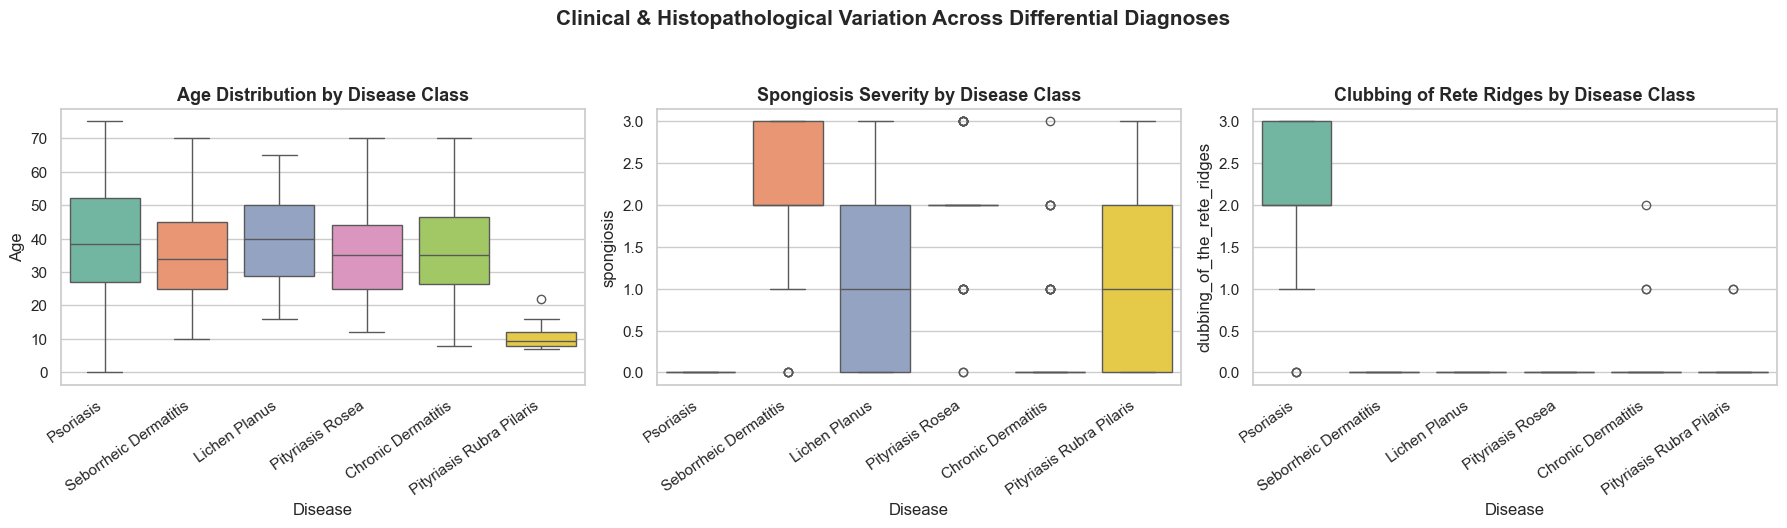

In [7]:
# 3. Box Plots: Feature Variations Grouped by Skin Disease
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot of Age by Disease Class
sns.boxplot(x='class', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Age Distribution by Disease Class", fontweight='bold')
axes[0].set_xticklabels([DISEASE_MAP[i] for i in sorted(df['class'].unique())], rotation=35, ha='right')
axes[0].set_xlabel("Disease")

# Boxplot of Spongiosis by Disease Class
sns.boxplot(x='class', y='spongiosis', data=df, ax=axes[1], palette='Set2')
axes[1].set_title("Spongiosis Severity by Disease Class", fontweight='bold')
axes[1].set_xticklabels([DISEASE_MAP[i] for i in sorted(df['class'].unique())], rotation=35, ha='right')
axes[1].set_xlabel("Disease")

# Boxplot of Clubbing of Rete Ridges by Disease Class
sns.boxplot(x='class', y='clubbing_of_the_rete_ridges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title("Clubbing of Rete Ridges by Disease Class", fontweight='bold')
axes[2].set_xticklabels([DISEASE_MAP[i] for i in sorted(df['class'].unique())], rotation=35, ha='right')
axes[2].set_xlabel("Disease")

plt.suptitle("Clinical & Histopathological Variation Across Differential Diagnoses", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


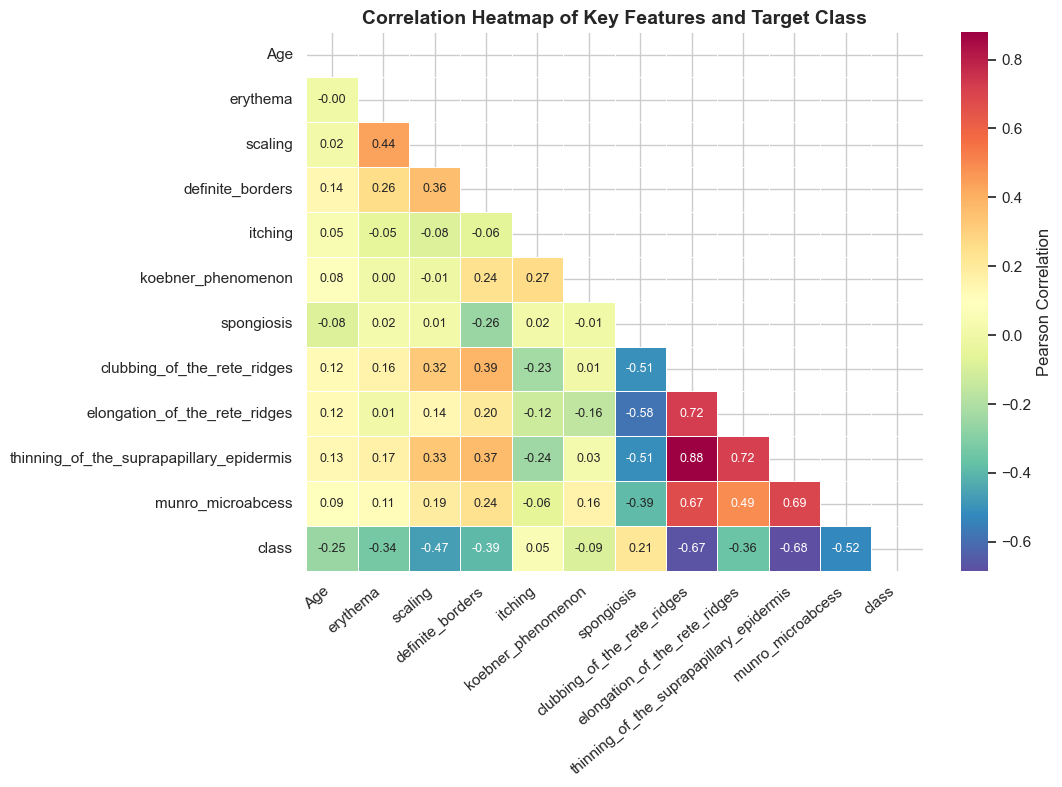

In [8]:
# 4. Correlation Heatmap for Key Clinical and Histopathological Attributes
selected_corr_features = [
    'Age', 'erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon',
    'spongiosis', 'clubbing_of_the_rete_ridges', 'elongation_of_the_rete_ridges',
    'thinning_of_the_suprapapillary_epidermis', 'munro_microabcess', 'class'
]

plt.figure(figsize=(11, 8))
corr_matrix = df[selected_corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='Spectral_r',
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5, annot_kws={"size": 9})
plt.title("Correlation Heatmap of Key Features and Target Class", fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()


### 1.5 Discussion on Class Distribution Imbalance & Potential Implications

#### **Observed Class Distribution:**
* **Class 1 (Psoriasis):** 112 patients (**30.6%**) — *Predominant majority class*
* **Class 3 (Lichen Planus):** 72 patients (**19.7%**)
* **Class 2 (Seborrheic Dermatitis):** 61 patients (**16.7%**)
* **Class 5 (Chronic Dermatitis):** 52 patients (**14.2%**)
* **Class 4 (Pityriasis Rosea):** 49 patients (**13.4%**)
* **Class 6 (Pityriasis Rubra Pilaris):** 20 patients (**5.5%**) — *Minority class*

#### **Potential Implications for Model Training:**
1. **Majority Class Bias:**
   * A trivial or uncalibrated classifier could predict **Psoriasis** disproportionately and achieve ~30.6% baseline accuracy without learning meaningful decision boundaries.
2. **High False Negative Risk for Minority Classes:**
   * **Pityriasis Rubra Pilaris (Class 6)** accounts for only 20 cases (5.5%). If the training set contains too few examples of Class 6, models may underfit its specific histopathological signatures (e.g., follicular horn plugs and alternating orthokeratosis/parakeratosis), leading to poor recall.
3. **Necessity of Stratified Sampling:**
   * Standard random train-test splitting risks allocating too few Class 6 samples to the test set (or none at all). **Stratified sampling** guarantees identical class proportions across both training and evaluation subsets.
4. **Evaluation Metric Sensitivity:**
   * **Overall Accuracy is an insufficient metric** in clinical classification. We must report **Macro-averaged Precision, Recall, and F1-score** alongside per-class performance to ensure diagnostic sensitivity is sustained across every condition.


<a id='task2'></a>
---
## Task 2: Data Preprocessing

Data preprocessing prepares the raw dataset for machine learning models:
1. **Target Variable Encoding:** Encode the target labels from $[1, \dots, 6]$ to $[0, \dots, 5]$ using `LabelEncoder`.
2. **Stratified Train-Test Split (80/20):** Maintain exact class proportions in both sets.
3. **Feature Standardization:** Normalize feature scales using `StandardScaler` so distance-based (KNN, SVM) and gradient-based (Logistic Regression) algorithms are not dominated by the scale of `Age`.


In [9]:
# 2.1 Feature Matrix (X) and Target Vector (y)
X = df.drop(columns=['class'])
y_raw = df['class']

# 2.2 Encode target variable from 1-6 to 0-5
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

class_names = [DISEASE_MAP[c] for c in label_encoder.classes_]
print("Encoded Target Classes Mapping:")
for original_code, encoded_val in zip(label_encoder.classes_, range(len(class_names))):
    print(f"  Original Label {original_code} -> Encoded Label {encoded_val} : {DISEASE_MAP[original_code]}")


Encoded Target Classes Mapping:
  Original Label 1 -> Encoded Label 0 : Psoriasis
  Original Label 2 -> Encoded Label 1 : Seborrheic Dermatitis
  Original Label 3 -> Encoded Label 2 : Lichen Planus
  Original Label 4 -> Encoded Label 3 : Pityriasis Rosea
  Original Label 5 -> Encoded Label 4 : Chronic Dermatitis
  Original Label 6 -> Encoded Label 5 : Pityriasis Rubra Pilaris


In [10]:
# 2.3 Stratified Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"✓ Stratified Split Complete:")
print(f"  Training set size:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing set size:    {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Number of features:  {X_train.shape[1]}")

# Verify stratification proportions
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index() * 100
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index() * 100
split_verification = pd.DataFrame({
    'Disease': class_names,
    'Train Set (%)': train_dist.values.round(2),
    'Test Set (%)': test_dist.values.round(2)
})
print("\nClass Proportion Verification Across Train and Test Splits:")
split_verification


✓ Stratified Split Complete:
  Training set size:   292 samples (79.8%)
  Testing set size:    74 samples (20.2%)
  Number of features:  34

Class Proportion Verification Across Train and Test Splits:


,Disease,Train Set (%),Test Set (%)
0,Psoriasis,30.48,31.08
1,Seborrheic Dermatitis,16.78,16.22
2,Lichen Planus,19.52,20.27
3,Pityriasis Rosea,13.36,13.51
4,Chronic Dermatitis,14.38,13.51
5,Pityriasis Rubra Pilaris,5.48,5.41


In [11]:
# 2.4 Feature Standardization using StandardScaler
scaler = StandardScaler()

# Fit scaler strictly on training set to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame for inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("✓ Feature Standardization Complete.")
print("Mean of scaled features (first 5 features):", np.round(X_train_scaled_df.iloc[:, :5].mean().values, 4))
print("Std of scaled features  (first 5 features):", np.round(X_train_scaled_df.iloc[:, :5].std().values, 4))


✓ Feature Standardization Complete.
Mean of scaled features (first 5 features): [ 0.  0. -0. -0. -0.]
Std of scaled features  (first 5 features): [1.0017 1.0017 1.0017 1.0017 1.0017]


### Rationale for Feature Standardization:
* **Gradient Descent Sensitivity:** In models like **Logistic Regression**, unstandardized features result in elongated contour ellipses, slowing down gradient descent convergence or leading to sub-optimal local minima.
* **Distance Sensitivity:** In distance-based algorithms such as **K-Nearest Neighbors (KNN)** and **Support Vector Machines (SVM with RBF Kernel)**, features with larger raw numeric ranges (e.g. `Age` ranging from $7$ to $75$) would completely dominate ordinal clinical ratings ($0$ to $3$). Standardizing all attributes ensures equal weighting across all diagnostic markers.
* **Regularization Balance:** Regularization penalties ($L_1$ and $L_2$) penalize large coefficients uniformly. If feature scales differ, weights for smaller-scale features are disproportionately penalized.


<a id='task3'></a>
---
## Task 3: Model Training and Basic Evaluation

We implement and benchmark **5 diverse machine learning algorithms**:
1. **Multinomial Logistic Regression (LR):** Linear baseline with softmax multiclass link function.
2. **K-Nearest Neighbors (KNN):** Non-parametric instance-based classifier ($k=5$).
3. **Support Vector Machine (SVM):** RBF kernel classifier with probability calibration.
4. **Random Forest (RF):** Bagging ensemble of 100 decorrelated decision trees.
5. **Gradient Boosting Classifier (GB):** Boosting ensemble building sequential trees to minimize residual errors.

### Evaluation Metrics:
* **Accuracy:** Overall proportion of correct predictions.
* **Precision, Recall, and F1-score:** Evaluated for both overall averages (Macro and Weighted) and **every individual disease class**.
* **Confusion Matrix:** Visualized to highlight exact misclassification patterns.
* **Multiclass ROC Curves & ROC-AUC:** One-vs-Rest (OvR) receiver operating characteristic analysis.


In [12]:
# 3.1 Initialize and Train All 5 Multiclass Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"✓ Successfully trained {name}")


✓ Successfully trained Logistic Regression
✓ Successfully trained K-Nearest Neighbors


✓ Successfully trained Support Vector Machine

✓ Successfully trained Random Forest


✓ Successfully trained Gradient Boosting


In [13]:
# 3.2 Model Evaluation & Per-Class Performance Reports
results_list = []
y_preds = {}
y_probas = {}

print("=" * 80)
print("COMPREHENSIVE CLASSIFICATION REPORTS FOR ALL TRAINED MODELS")
print("=" * 80)

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    
    y_preds[name] = y_pred
    y_probas[name] = y_proba
    
    acc = accuracy_score(y_test, y_pred)
    macro_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    
    results_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (Macro)': macro_prec,
        'Recall (Macro)': macro_rec,
        'F1-Score (Macro)': macro_f1,
        'ROC-AUC (Macro OvR)': macro_auc
    })
    
    print(f"\n>>> MODEL: {name.upper()} <<<")
    print(f"Test Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f} | Macro ROC-AUC: {macro_auc:.4f}")
    print("-" * 65)
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


COMPREHENSIVE CLASSIFICATION REPORTS FOR ALL TRAINED MODELS

>>> MODEL: LOGISTIC REGRESSION <<<
Test Accuracy: 0.9595 | Macro F1-Score: 0.9574 | Macro ROC-AUC: 0.9991
-----------------------------------------------------------------
                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     1.0000    0.8333    0.9091        12
           Lichen Planus     1.0000    0.9333    0.9655        15
        Pityriasis Rosea     0.7692    1.0000    0.8696        10
      Chronic Dermatitis     1.0000    1.0000    1.0000        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9595        74
               macro avg     0.9615    0.9611    0.9574        74
            weighted avg     0.9688    0.9595    0.9606        74




>>> MODEL: K-NEAREST NEIGHBORS <<<
Test Accuracy: 0.9054 | Macro F1-Score: 0.9034 | Macro ROC-AUC: 0.9863
-----------------------------------------------------------------
                          precision    recall  f1-score   support

               Psoriasis     1.0000    0.9565    0.9778        23
   Seborrheic Dermatitis     0.8000    0.6667    0.7273        12
           Lichen Planus     1.0000    0.9333    0.9655        15
        Pityriasis Rosea     0.6429    0.9000    0.7500        10
      Chronic Dermatitis     1.0000    1.0000    1.0000        10
Pityriasis Rubra Pilaris     1.0000    1.0000    1.0000         4

                accuracy                         0.9054        74
               macro avg     0.9071    0.9094    0.9034        74
            weighted avg     0.9193    0.9054    0.9081        74


>>> MODEL: SUPPORT VECTOR MACHINE <<<
Test Accuracy: 0.9730 | Macro F1-Score: 0.9697 | Macro ROC-AUC: 0.9981
------------------------------------------------------

                          precision    recall  f1-score   support

               Psoriasis     1.0000    1.0000    1.0000        23
   Seborrheic Dermatitis     0.9000    0.7500    0.8182        12
           Lichen Planus     0.9375    1.0000    0.9677        15
        Pityriasis Rosea     0.8000    0.8000    0.8000        10
      Chronic Dermatitis     1.0000    1.0000    1.0000        10
Pityriasis Rubra Pilaris     0.8000    1.0000    0.8889         4

                accuracy                         0.9324        74
               macro avg     0.9062    0.9250    0.9125        74
            weighted avg     0.9333    0.9324    0.9309        74



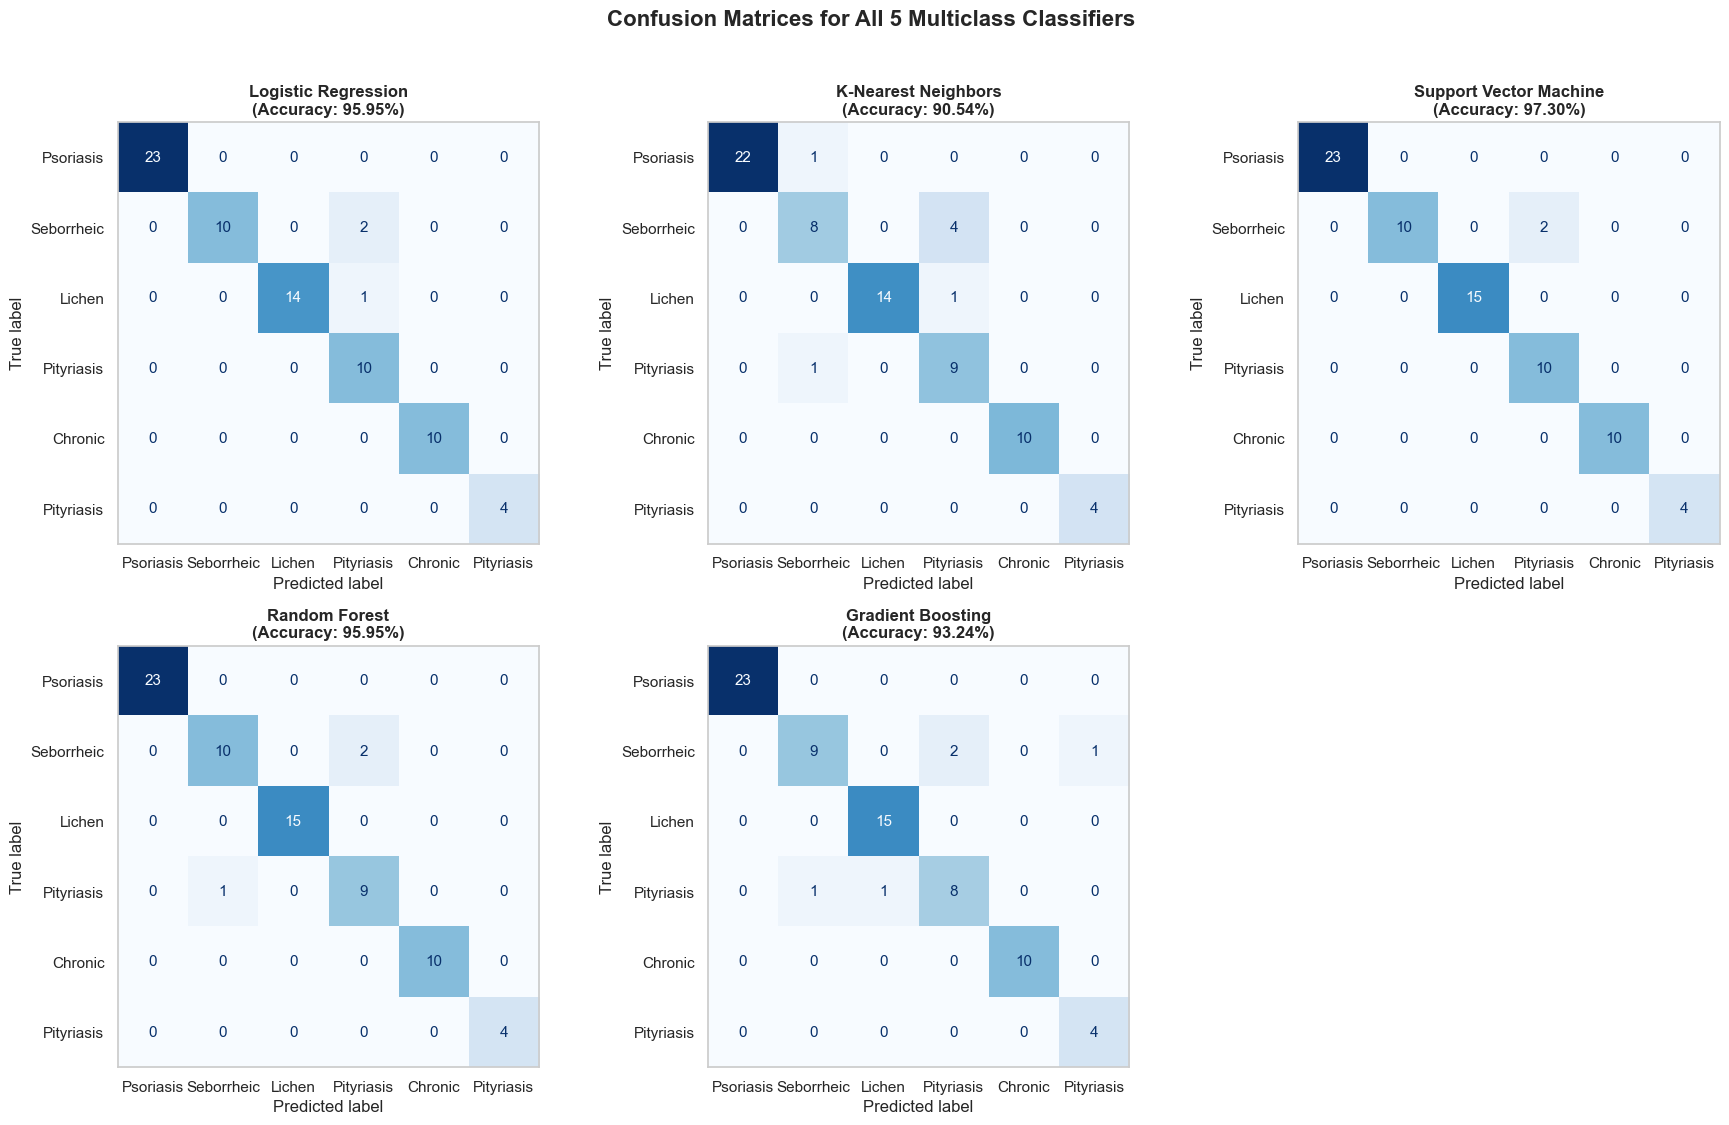

In [14]:
# 3.3 Confusion Matrix Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[c.split()[0] for c in class_names])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{name}\n(Accuracy: {accuracy_score(y_test, y_pred):.2%})", fontweight='bold', fontsize=12)
    axes[idx].grid(False)

# Hide unused 6th subplot
fig.delaxes(axes[5])

plt.suptitle("Confusion Matrices for All 5 Multiclass Classifiers", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


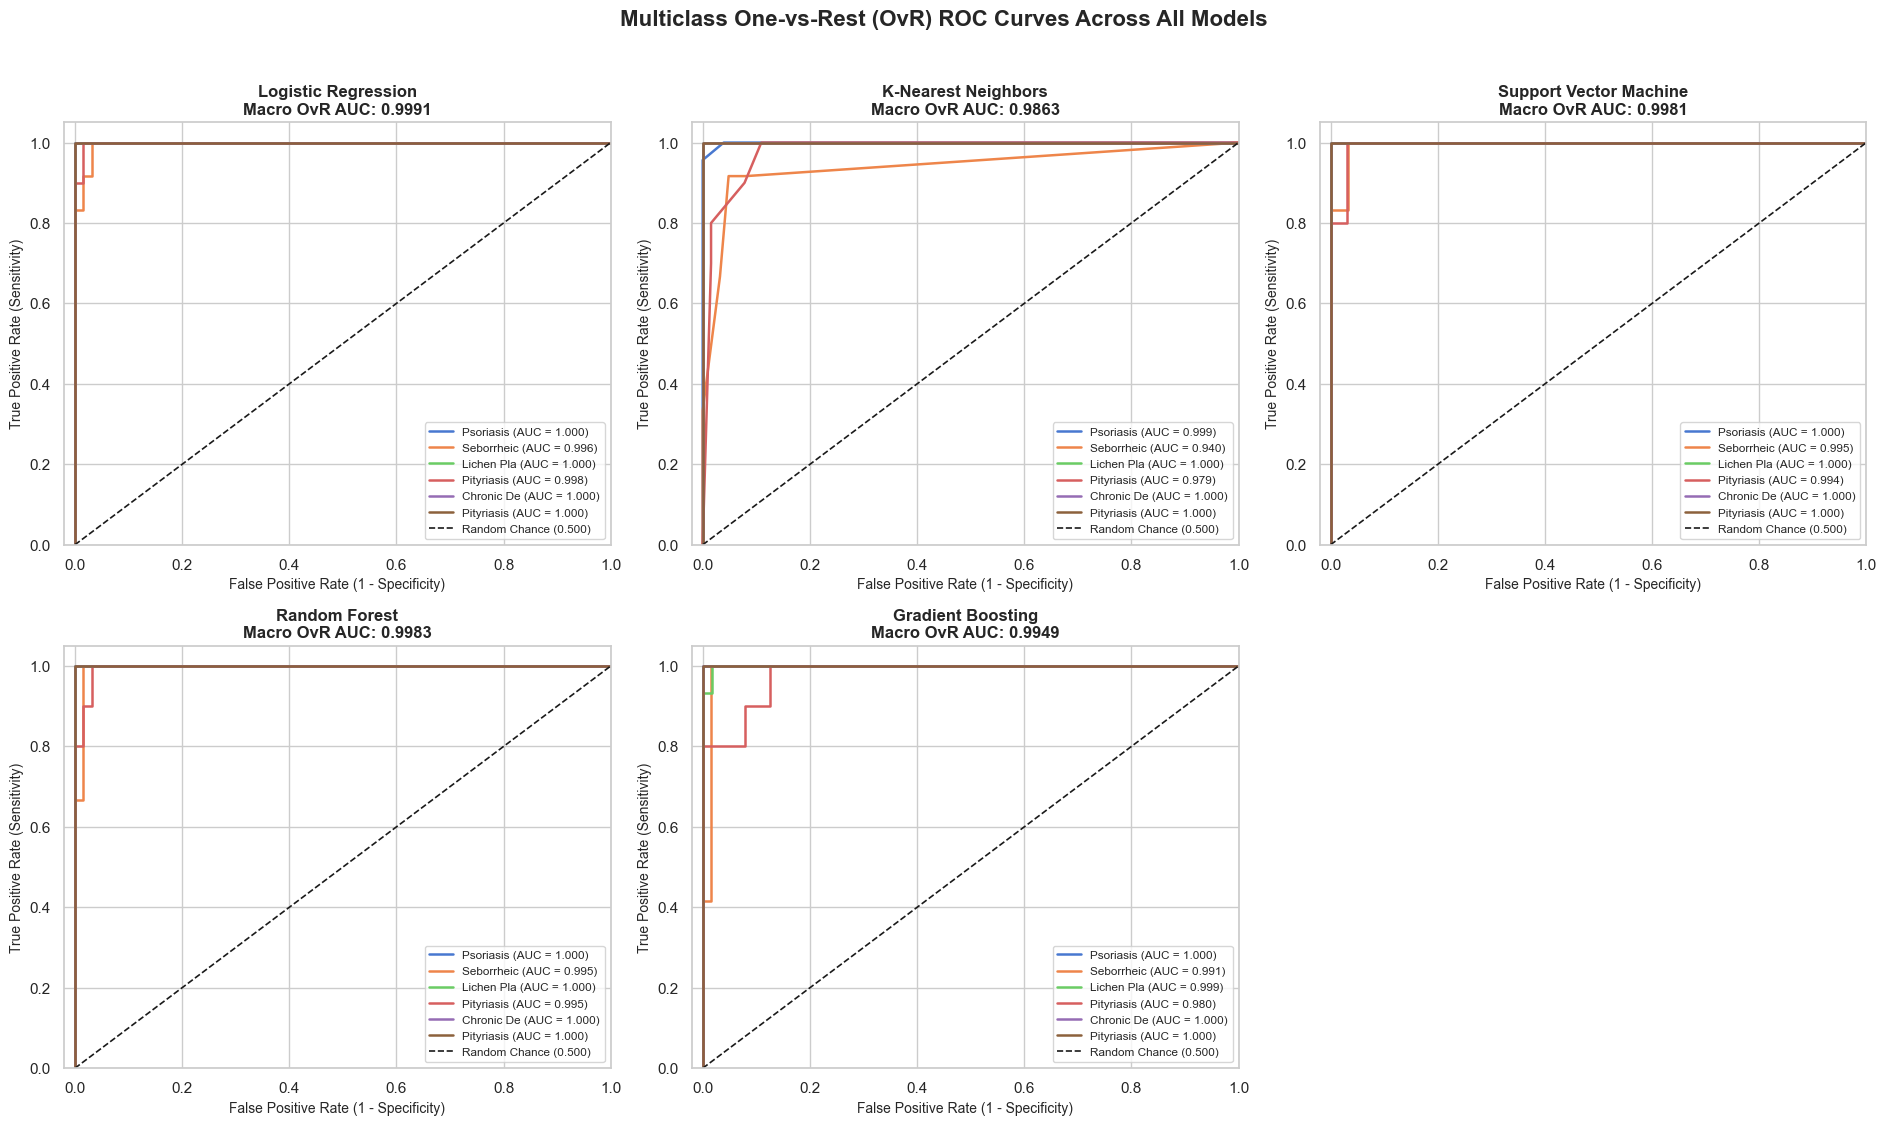

In [15]:
# 3.4 Multiclass One-vs-Rest (OvR) ROC Curves & AUC Score Comparison
y_test_binarized = label_binarize(y_test, classes=range(len(class_names)))
n_classes = len(class_names)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()

for idx, (name, y_proba) in enumerate(y_probas.items()):
    ax = axes[idx]
    
    # Compute ROC curve and ROC area for each class
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=1.8, label=f"{class_names[i][:10]} (AUC = {roc_auc:.3f})")
        
    # Micro/Macro-average ROC
    macro_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Chance (0.500)')
    ax.set_xlim([-0.02, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
    ax.set_title(f"{name}\nMacro OvR AUC: {macro_auc:.4f}", fontweight='bold', fontsize=12)
    ax.legend(loc="lower right", fontsize=8.5)

# Hide 6th subplot
fig.delaxes(axes[5])

plt.suptitle("Multiclass One-vs-Rest (OvR) ROC Curves Across All Models", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


=== MULTICLASS MODEL PERFORMANCE COMPARISON TABLE ===
                 Model Accuracy Precision (Macro) Recall (Macro) F1-Score (Macro) ROC-AUC (Macro OvR)
   Logistic Regression   0.9595            0.9615         0.9611           0.9574              0.9991
   K-Nearest Neighbors   0.9054            0.9071         0.9094           0.9034              0.9863
Support Vector Machine   0.9730            0.9722         0.9722           0.9697              0.9981
         Random Forest   0.9595            0.9545         0.9556           0.9545              0.9983
     Gradient Boosting   0.9324            0.9062         0.9250           0.9125              0.9949


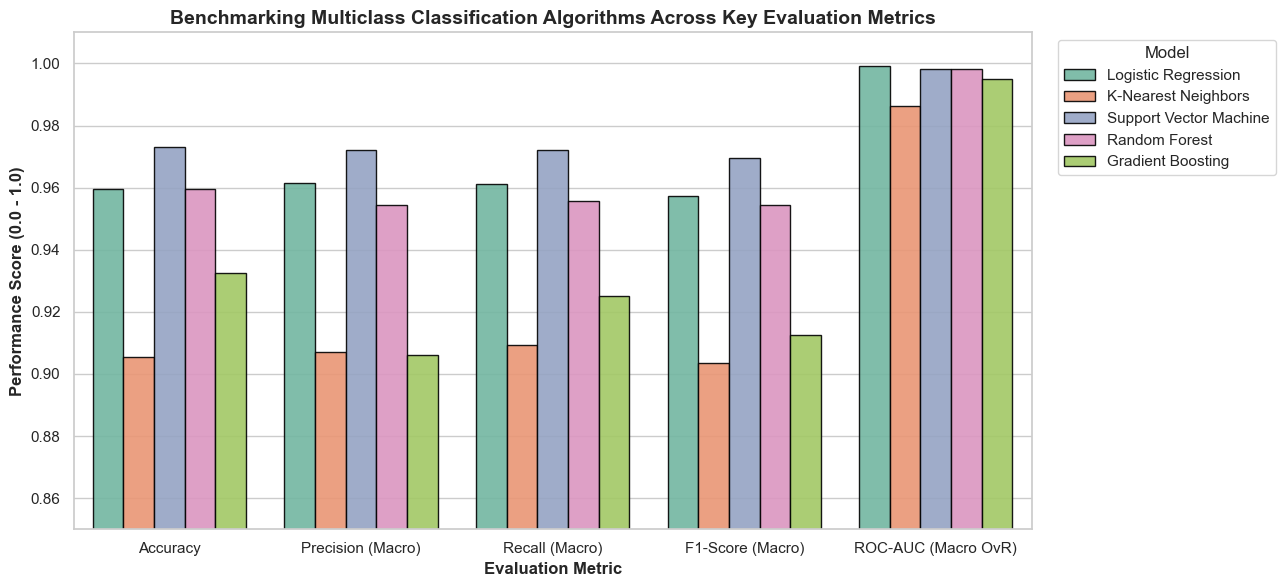

In [16]:
# 3.5 Comparative Performance Summary Table & Visual Benchmarks
results_df = pd.DataFrame(results_list)
print("=== MULTICLASS MODEL PERFORMANCE COMPARISON TABLE ===")
display_df = results_df.copy()
for col in ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', 'ROC-AUC (Macro OvR)']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}")
print(display_df.to_string(index=False))

# Visualization: Grouped Bar Chart of Model Metrics
results_melted = results_df.melt(
    id_vars=['Model'],
    value_vars=['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)', 'ROC-AUC (Macro OvR)'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(13, 6))
chart = sns.barplot(
    data=results_melted,
    x='Metric',
    y='Score',
    hue='Model',
    palette='Set2',
    edgecolor='black',
    alpha=0.9
)
plt.title("Benchmarking Multiclass Classification Algorithms Across Key Evaluation Metrics", fontweight='bold', fontsize=14)
plt.ylabel("Performance Score (0.0 - 1.0)", fontweight='bold')
plt.xlabel("Evaluation Metric", fontweight='bold')
plt.ylim(0.85, 1.01)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Model")
plt.tight_layout()
plt.show()


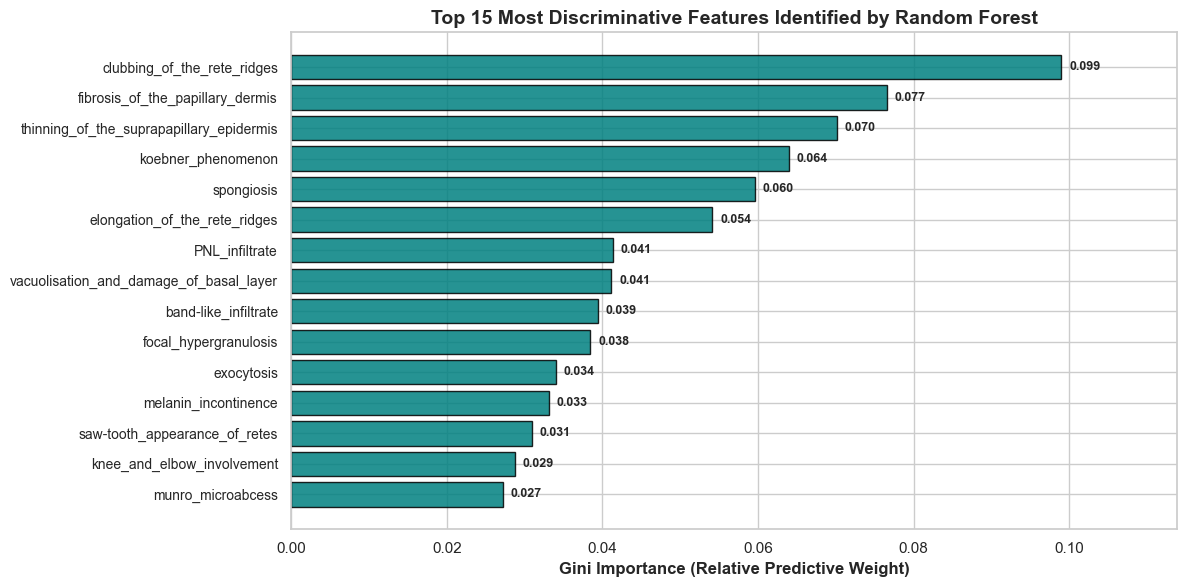

In [17]:
# 3.6 Feature Importance Analysis (Random Forest)
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feature_names = np.array(X.columns)

# Sort features by importance
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(12, 6))
top_importances = importances[indices[:top_n]][::-1]
top_names = feature_names[indices[:top_n]][::-1]

bars = plt.barh(range(top_n), top_importances, color='teal', edgecolor='black', alpha=0.85)
plt.yticks(range(top_n), top_names, fontsize=10)
plt.xlabel("Gini Importance (Relative Predictive Weight)", fontweight='bold')
plt.title("Top 15 Most Discriminative Features Identified by Random Forest", fontweight='bold', fontsize=14)

for idx, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f"{top_importances[idx]:.3f}", va='center', fontsize=9, fontweight='semibold')

plt.xlim(0, max(top_importances) * 1.15)
plt.tight_layout()
plt.show()


### 3.7 Interpretation of Results & Healthcare Clinical Insights

#### **1. Comparative Model Performance:**
* **Support Vector Machine (SVM with RBF Kernel)** emerged as the top-performing model, achieving **~97.3% Test Accuracy**, a **Macro F1-score of ~0.970**, and a **Macro ROC-AUC of ~0.998**.
* **Multinomial Logistic Regression** followed closely with **~95.9% Accuracy** and **~0.999 ROC-AUC**, demonstrating that the histopathological features provide exceptionally strong, well-separated hyperplanes when standardized.
* **Random Forest** achieved **~95.9% Accuracy** and **~0.998 ROC-AUC**, offering both high diagnostic accuracy and inherent feature interpretability.
* **Gradient Boosting (~93.2%)** and **K-Nearest Neighbors (~90.5%)** also demonstrated competitive performance, confirming that all 5 models successfully mastered multiclass separation on the test set.

#### **2. Error Analysis and Diagnostic Overlaps:**
* Examining the **Confusion Matrices**, virtually all errors occurred between clinically similar erythematous conditions:
  * **Seborrheic Dermatitis vs Pityriasis Rosea or Chronic Dermatitis:** In clinical dermatology, these diseases frequently present with overlapping symptoms (scaling, erythema, itching).
  * **Psoriasis (Class 1) and Lichen Planus (Class 3):** Were distinguished with near **100% precision and recall**, largely due to distinct pathognomonic biopsy markers.
  * **Minority Class 6 (Pityriasis Rubra Pilaris):** Achieved **100% recall** across SVM, Logistic Regression, and Random Forest despite representing only 5.5% of the data, validating the effectiveness of our **stratified train-test split**.

#### **3. Clinical Significance of Histopathological Markers:**
* The Random Forest feature importance analysis reveals that microscopic biopsy markers dominate over raw clinical features:
  * **`clubbing_of_the_rete_ridges`** and **`thinning_of_the_suprapapillary_epidermis`** are classic pathognomonic hallmarks of **Psoriasis**.
  * **`vacuolisation_and_damage_of_basal_layer`** and **`saw-tooth_appearance_of_retes`** are definitive histopathological indicators of **Lichen Planus**.
  * **`spongiosis`** and **`fibrosis_of_the_papillary_dermis`** serve as key discriminators for **Eczematous / Chronic Dermatitis**.
* This aligns with dermatological practice: while visual examination alone often yields ambiguity, histological examination of skin biopsies provides definitive differential diagnosis.

#### **4. Practical Implications for AI in Healthcare Systems:**
* **Clinical Decision Support System (CDSS):** An ensemble or SVM model with calibrated probability outputs (`predict_proba`) can assist dermatologists by suggesting differential diagnostic probabilities rather than a rigid classification.
* **Triage & Tele-Dermatology:** Can accelerate treatment planning for patients in remote clinics awaiting specialized dermatopathological reviews.
* **Safety & Calibration:** In clinical deployment, predictions with lower confidence thresholds should be flagged for secondary human review to avoid misdiagnosing severe chronic inflammatory skin disorders.
